# Wykresy do wyników

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.dirname(SCRIPT_DIR))
DATA_PATH = os.path.join(PROJECT_ROOT, 'all_models_metrics_comparison.csv')
PLOTS_DIR = os.path.join(SCRIPT_DIR, 'plots', 'results')

TITLE_FONT_SIZE = 18
AXIS_FONT_SIZE = 14
TICK_FONT_SIZE = 12

In [38]:
df = pd.read_csv(DATA_PATH, sep = ';', decimal = ',')

metrics_cols = ['MAE', 'RMSE', 'MAPE', 'Direction_Accuracy_Pct', 'Execution_Time_Sec']
for col in metrics_cols:
    df[col] = pd.to_numeric(df[col].astype(str).replace('-', np.nan), errors='coerce')

df.rename(columns={df.columns[0]: 'Model'}, inplace=True)

df.columns = [col.replace('_', ' ') for col in df.columns]

unique_models = df['Model'].unique()
colors = sns.color_palette("tab10", len(unique_models))
model_colors = dict(zip(unique_models, colors))

df.head(6)

,Model,MAE,RMSE,MAPE,Direction Accuracy Pct,Execution Time Sec
0,CART,45.206483,62.639030,0.878478,59.538275,17.904821
1,XGBoost,45.168401,62.649993,0.878341,57.837181,108.968847
2,LSTM,45.374475,63.247577,0.883198,57.108141,665.295437
3,ARIMA,45.974855,64.799846,0.894475,54.678007,215.660179
4,Naive,46.157363,64.570208,0.897779,NaN,0.024873
5,Naive trend,66.473852,91.874651,1.294504,53.462940,0.038600


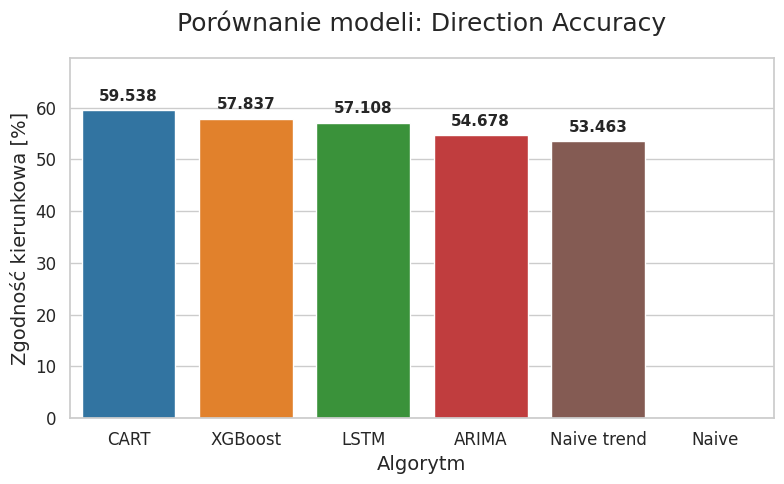

In [ ]:
metric_to_plot = 'Direction Accuracy Pct' 

# Sortowanie danych
df_plot = df.sort_values(by=metric_to_plot, ascending=False)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Model', 
    y=metric_to_plot, 
    data=df_plot, 
    palette=model_colors,
    hue='Model',
    legend=False
)

# Dodanie etykiet
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            format(p.get_height(), '.3f'), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 10), 
            textcoords='offset points',
            fontsize=11, fontweight='bold'
        )

plt.title(f'Porównanie modeli: Direction Accuracy', fontsize=TITLE_FONT_SIZE, pad=20)
plt.ylabel('Zgodność kierunkowa [%]', fontsize=AXIS_FONT_SIZE)
plt.xlabel('Algorytm', fontsize=AXIS_FONT_SIZE)
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE)

y_min = 0
y_max = df_plot[metric_to_plot].max() + 10.0
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'DA.png'), dpi=300, bbox_inches='tight')
plt.show()

Zapisano: /home/rafal/BEng-thesis-code/BENG-thesis_code/analysis_data/plots/results/poprawa_relative_MAE.png


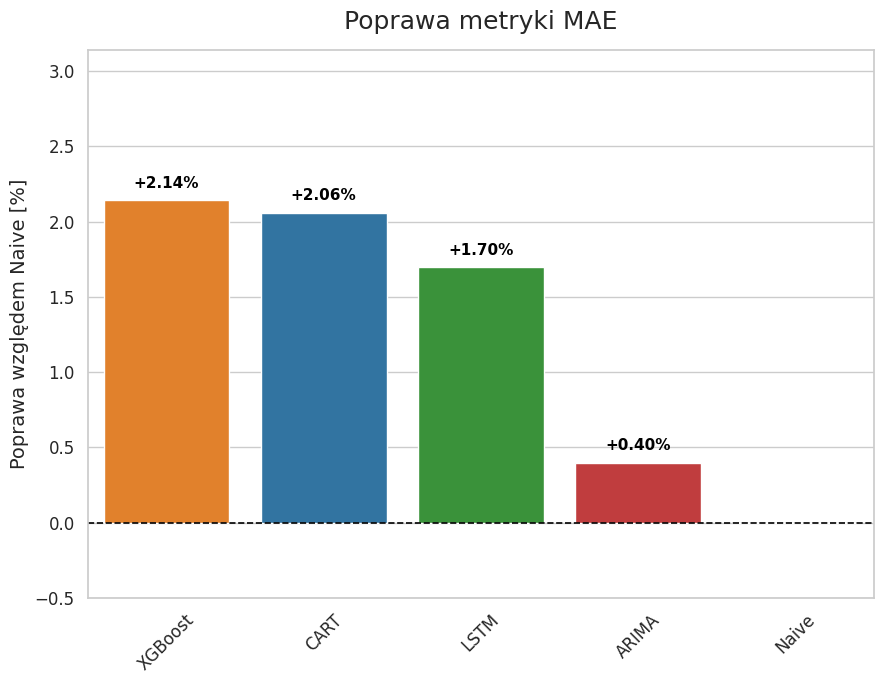

Zapisano: /home/rafal/BEng-thesis-code/BENG-thesis_code/analysis_data/plots/results/poprawa_relative_RMSE.png


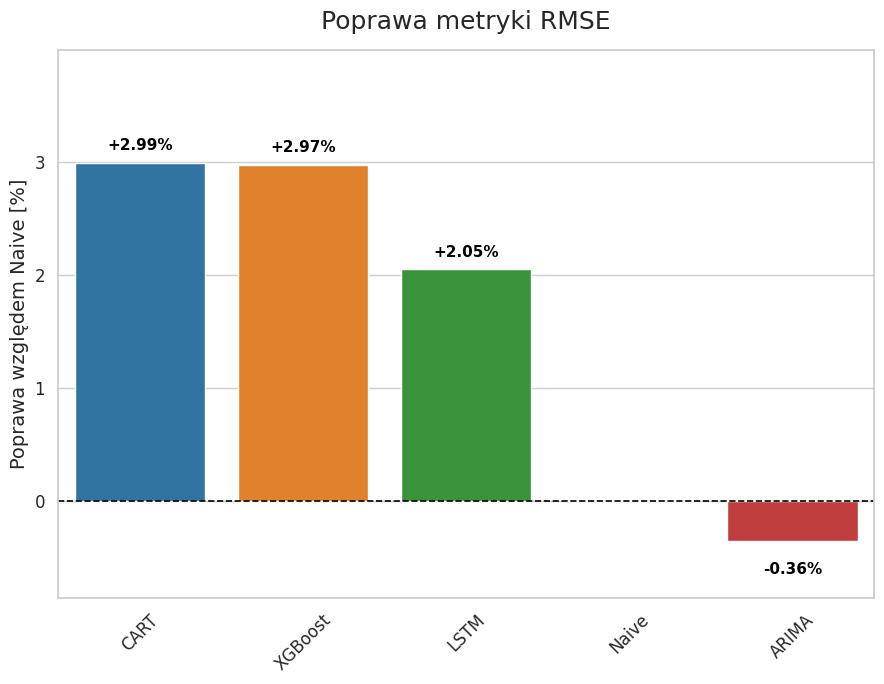

Zapisano: /home/rafal/BEng-thesis-code/BENG-thesis_code/analysis_data/plots/results/poprawa_relative_MAPE.png


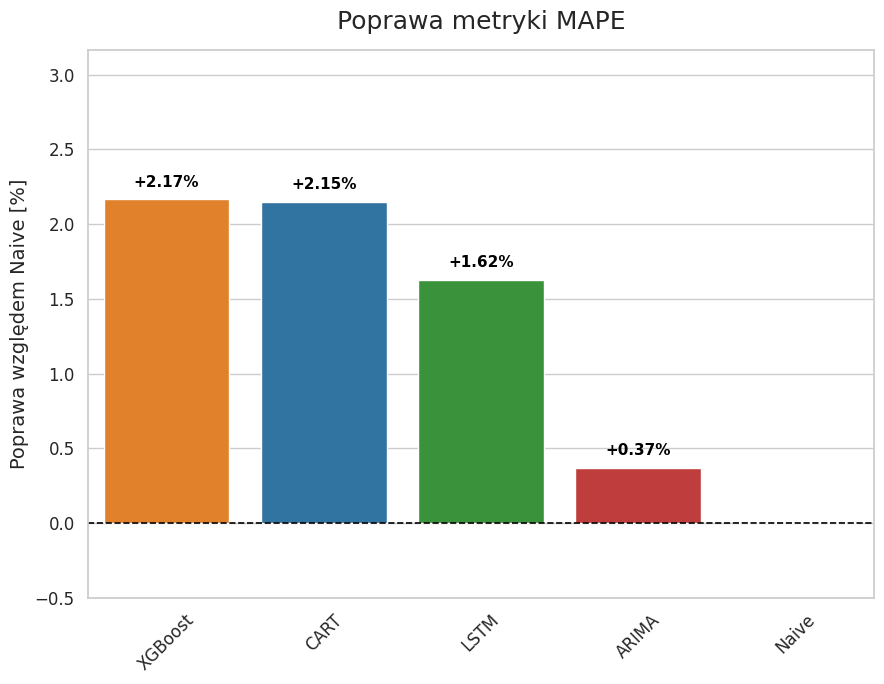

In [ ]:
# 1. Filtrowanie danych
df_filtered = df[df['Model'] != 'Naive trend'].copy()
comparison_metrics = ['MAE', 'RMSE', 'MAPE']

sns.set_theme(style="whitegrid")

for metric in comparison_metrics:
    plt.figure(figsize=(9, 7))
    
    # Obliczenia
    naive_val = df_filtered.loc[df_filtered['Model'] == 'Naive', metric].values[0]
    temp_df = df_filtered.copy()
    temp_df['Improvement'] = ((naive_val - temp_df[metric]) / naive_val) * 100
    temp_df = temp_df.sort_values(by='Improvement', ascending=False)
    
    # Wykres
    ax = sns.barplot(
        x='Model', 
        y='Improvement', 
        data=temp_df, 
        palette=model_colors,
        hue='Model',
        legend=False
    )
    
    plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
    
    # Etykiety nad/pod słupkami
    for p in ax.patches:
        height = p.get_height()
        if abs(height) > 0.001:
            ax.annotate(
                f'{height:+.2f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom' if height > 0 else 'top', 
                xytext=(0, 7 if height > 0 else -15), 
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='black'
            )
    
    # Stylizacja
    plt.title(f'Poprawa metryki {metric}', fontsize=TITLE_FONT_SIZE, pad=15)
    plt.ylabel('Poprawa względem Naive [%]', fontsize=AXIS_FONT_SIZE)
    plt.xlabel('', fontsize=AXIS_FONT_SIZE)
    plt.xticks(fontsize=TICK_FONT_SIZE, rotation=45)
    plt.yticks(fontsize=TICK_FONT_SIZE)
    
    # Powrót do Twoich oryginalnych limitów
    y_min = temp_df['Improvement'].min() - 0.5
    y_max = temp_df['Improvement'].max() + 1.0
    plt.ylim(y_min, y_max)

    plt.tight_layout()
    
    # Zapis
    save_path = os.path.join(PLOTS_DIR, f'poprawa_relative_{metric}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Zapisano: {save_path}")

    plt.show()
    plt.close() 

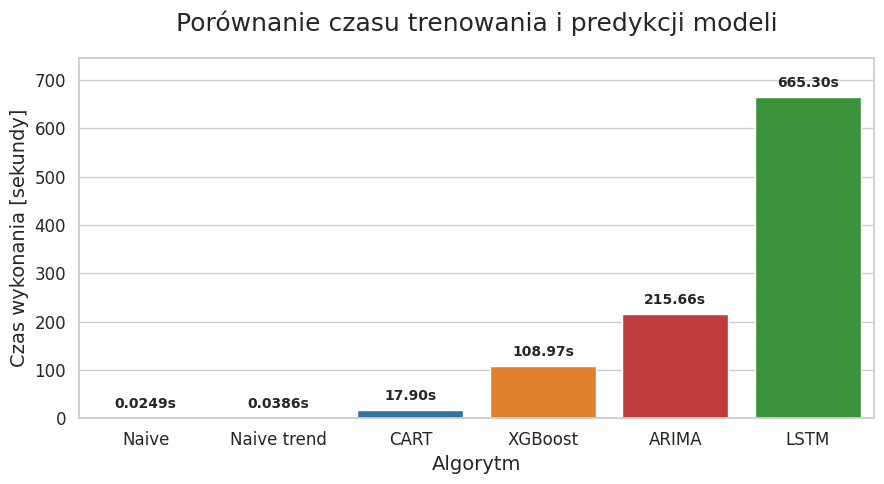

In [ ]:
# 1. Przygotowanie danych
metric_time = 'Execution Time Sec'
df_time = df.sort_values(by=metric_time, ascending=True)

# 2. Inicjalizacja wykresu
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 3. Rysowanie słupków z zachowaniem stałych kolorów
ax = sns.barplot(
    x='Model', 
    y=metric_time, 
    data=df_time, 
    palette=model_colors,
    hue='Model',
    legend=False
)

# 4. Dodanie etykiet nad słupkami
for p in ax.patches:
    height = p.get_height()
    label = f'{height:.2f}s' if height > 1 else f'{height:.4f}s'
    
    ax.annotate(
        label, 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='center', 
        xytext=(0, 10), 
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

# 5. Konfiguracja opisów
plt.title('Porównanie czasu trenowania i predykcji modeli', fontsize=TITLE_FONT_SIZE, pad=20)
plt.ylabel('Czas wykonania [sekundy]', fontsize=AXIS_FONT_SIZE)
plt.xlabel('Algorytm', fontsize=AXIS_FONT_SIZE)
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE)

y_min = 0
y_max = df_time[metric_time].max() + 80.0
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'porownanie_czasu.png'), dpi=300)
plt.show()

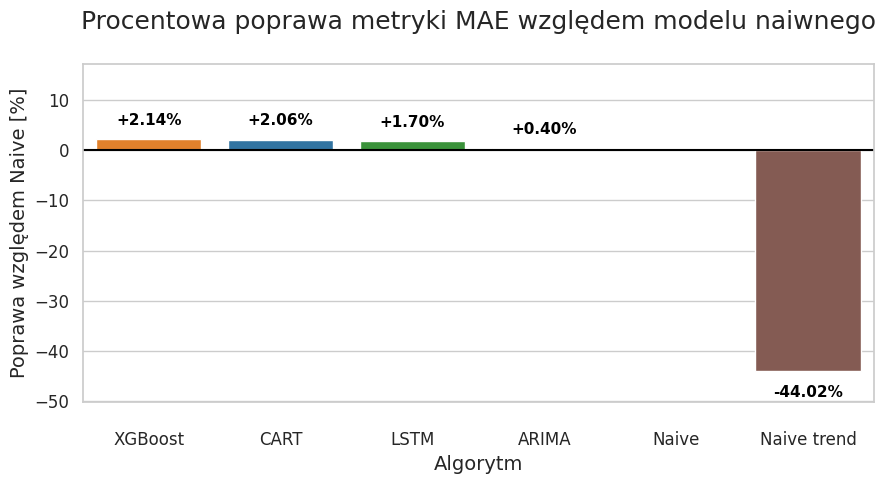

In [ ]:
# 1. Wybór metryki i obliczenia
base_metric = 'MAE'
naive_value = df.loc[df['Model'] == 'Naive', base_metric].values[0]
df['Poprawa %'] = ((naive_value - df[base_metric]) / naive_value) * 100

# 2. Przygotowanie danych
df_res = df.sort_values(by='Poprawa %', ascending=False)

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 3. Rysowanie wykresu
ax = sns.barplot(
    x='Model', 
    y='Poprawa %', 
    data=df_res, 
    palette=model_colors,
    hue='Model',
    legend=False
)

# 4. Dodanie linii bazowej 
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

# 5. Dodanie etykiet z zyskiem procentowym
for p in ax.patches:
    val = p.get_height()
    if abs(val) > 0.001:
        offset = 8 if val > 0 else -10 
        va = 'bottom' if val > 0 else 'top'
        
        ax.annotate(
            f'{val:+.2f}%', 
            (p.get_x() + p.get_width() / 2., val), 
            ha='center', va=va, 
            xytext=(0, offset), 
            textcoords='offset points',
            fontsize=11, fontweight='bold', color='black'
        )

# 6. Odsunięcie nazw modeli od osi
ax.tick_params(axis='x', which='major', pad=15)

# 7. Stylizacja i dynamiczne limity
plt.title(f'Procentowa poprawa metryki {base_metric} względem modelu naiwnego', fontsize=TITLE_FONT_SIZE, pad=25)
plt.ylabel('Poprawa względem Naive [%]', fontsize=AXIS_FONT_SIZE)
plt.xlabel('Algorytm', fontsize=AXIS_FONT_SIZE)
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE)

# Limity osi Y
y_min = df['Poprawa %'].min()
y_max = df['Poprawa %'].max()

top_margin = max(y_max * 0.5, 15) 
bottom_margin = abs(y_min) * 0.14

plt.ylim(y_min - bottom_margin, y_max + top_margin)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'MAE_naivet.png'), dpi=300)
plt.show()



Trafność w trend

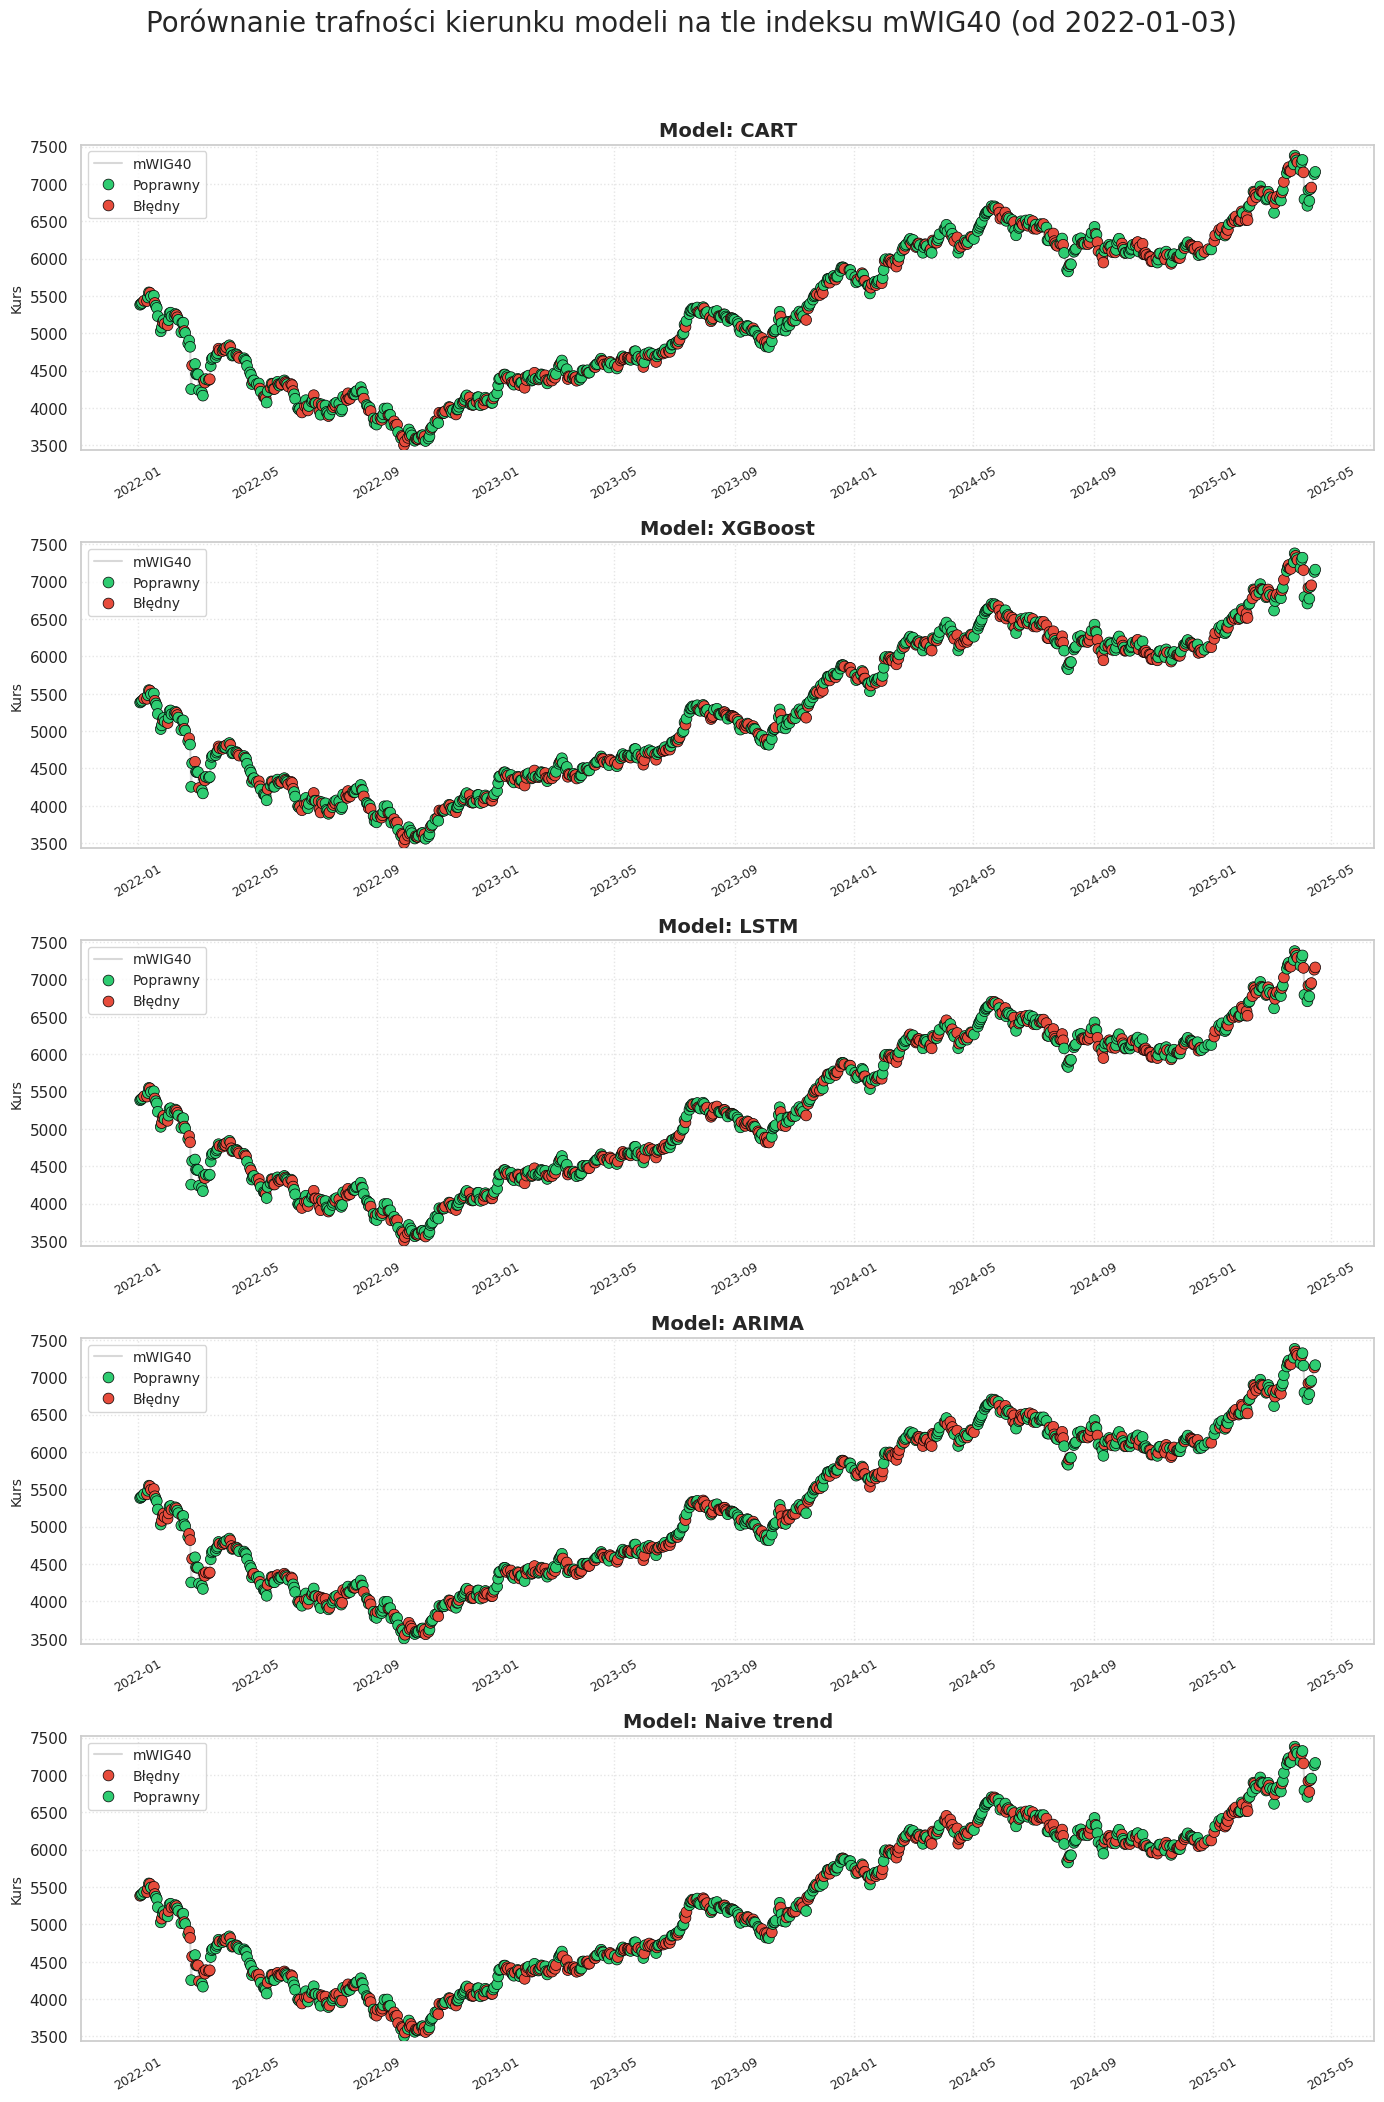

In [ ]:
# Słownik: Nazwa modelu -> Ścieżka do pliku CSV z wynikami tego modelu
xgb = os.path.join(PROJECT_ROOT, 'XGBoost', 'xgboost_output', 'xgboost_predictions.csv')
arima = os.path.join(PROJECT_ROOT, 'arima', 'arima_predictions.csv')
cart = os.path.join(PROJECT_ROOT, 'cart', 'cart_ret_output_selected_features', 'cart_predictions.csv')
lstm = os.path.join(PROJECT_ROOT, 'lstm', 'lstm_output', 'prediction_results' , 'lstm_predictions.csv')
naive = os.path.join(PROJECT_ROOT, 'naive', 'naive_predictions.csv')
naivet = os.path.join(PROJECT_ROOT, 'naive', 'naive_d_predictions.csv')

model_files = {
    #'Naive': naive,
    'CART': cart,
    'XGBoost': xgb,
    'LSTM': lstm,
    'ARIMA': arima,
    'Naive trend' : naivet
}

START_DATE = pd.to_datetime('2022-01-03') 
status_colors = {'Poprawny': '#2ecc71', 'Błędny': '#e74c3c'}

# Pobieramy listę modeli do wyświetlenia
models_to_plot = list(model_files.keys())
n_models = len(models_to_plot)
n_cols = 1
n_rows = (n_models + 1) // n_cols  # Obliczenie liczby wierszy dla układu 2-kolumnowego

# Tworzenie dużej figury pod macierz wykresów
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() # Spłaszczamy tablicę osi, aby łatwiej po niej iterować

for i, model_name in enumerate(models_to_plot):
    file_path = model_files[model_name]
    ax = axes[i]
    
    if not os.path.exists(file_path):
        ax.set_title(f"{model_name} - Brak pliku", color='red')
        continue
        
    # Wczytanie i przygotowanie danych
    df = pd.read_csv(file_path, sep=';', decimal=',')
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
    df_zoom = df[df.iloc[:, 0] >= START_DATE].copy()
    
    if df_zoom.empty:
        ax.set_title(f"{model_name} - Brak danych po {START_DATE.date()}")
        continue

    # Rysowanie linii kursu (Kolumna 1)
    ax.plot(df_zoom.iloc[:, 0], df_zoom.iloc[:, 1], color='gray', alpha=0.3, linewidth=1.5, label='mWIG40')
    
    # Sprawdzanie czy są kolumny ze zwrotami (min. 5 kolumn)
    if df_zoom.shape[1] >= 5:
        rzecz_zwrot = pd.to_numeric(df_zoom.iloc[:, 3], errors='coerce')
        prog_zwrot = pd.to_numeric(df_zoom.iloc[:, 4], errors='coerce')
        
        # Obliczenie kierunku
        df_zoom['Kierunek'] = np.where(
            (prog_zwrot != 0) & (np.sign(prog_zwrot) == np.sign(rzecz_zwrot)),
            'Poprawny', 'Błędny'
        )
        
        # Rysowanie punktów
        sns.scatterplot(
            data=df_zoom,
            x=df_zoom.columns[0], 
            y=df_zoom.columns[1],
            hue='Kierunek',
            palette=status_colors,
            s=60,
            edgecolor='black',
            linewidth=0.5,
            ax=ax,
            zorder=3
        )
        ax.legend(loc='upper left', fontsize='small')
    else:
        ax.set_title(f"{model_name} (Brak danych o kierunku)")

    # Stylizacja pojedynczego subplotu
    ax.set_title(f'Model: {model_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Kurs', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    
    # Skalowanie osi Y
    y_min, y_max = df_zoom.iloc[:, 1].min(), df_zoom.iloc[:, 1].max()
    ax.set_ylim(y_min * 0.98, y_max * 1.02)
    ax.grid(True, linestyle=':', alpha=0.5)

# Usuwamy puste osie, jeśli liczba modeli jest nieparzysta
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Porównanie trafności kierunku modeli na tle indeksu mWIG40 (od {START_DATE.date()})', 
             fontsize=20, y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'macierz_trafnosci_kierunku.png'), dpi=300, bbox_inches='tight')
plt.show()

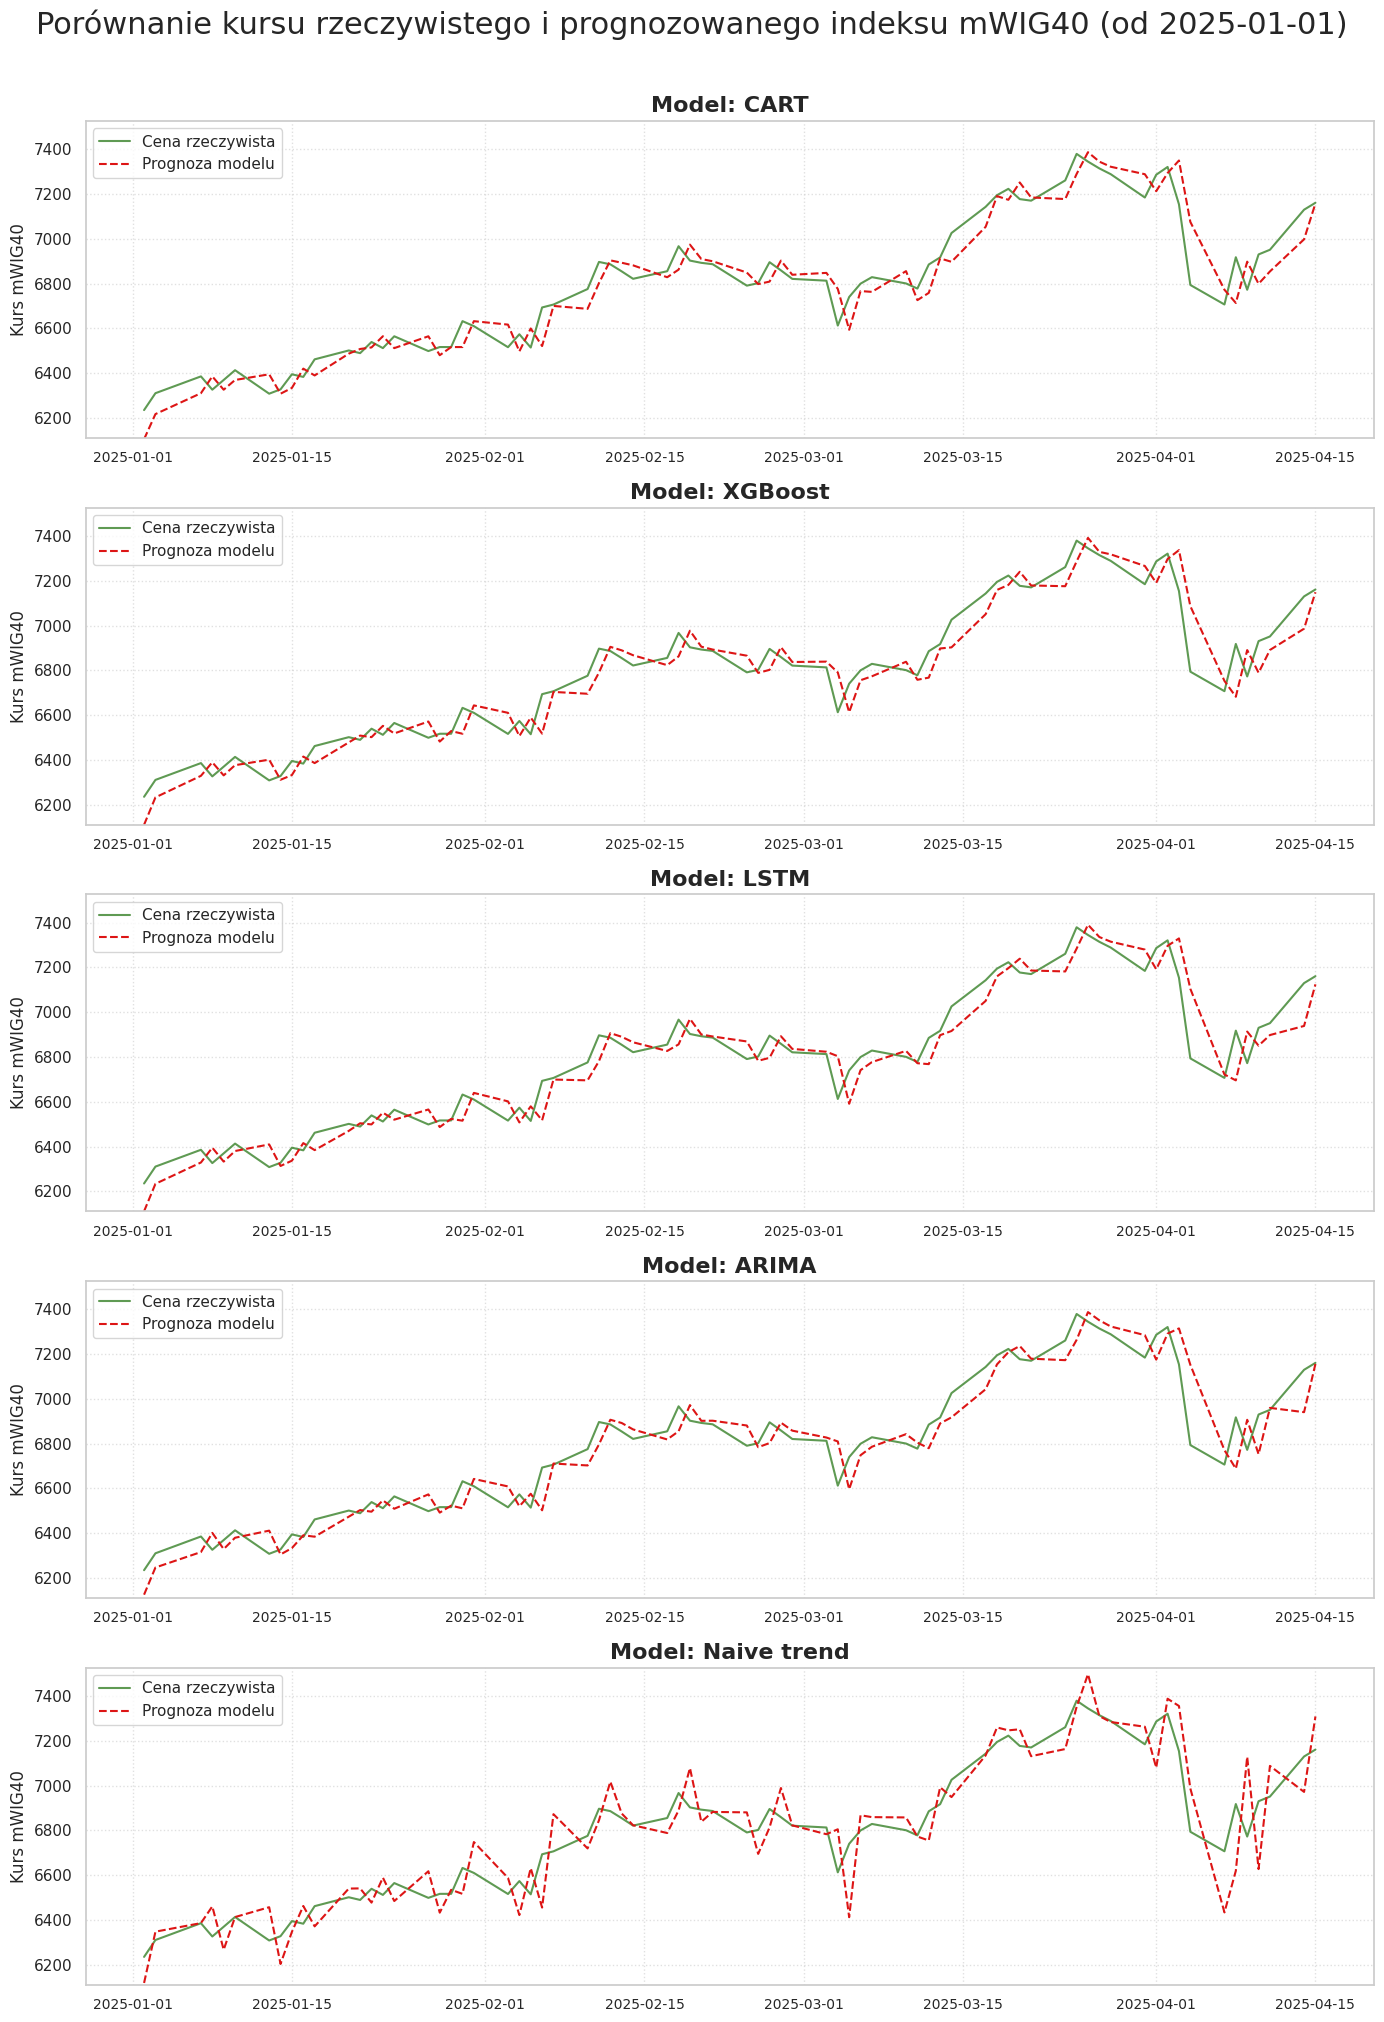

In [ ]:
START_DATE = pd.to_datetime('2025-01-01') 

# Kolory dla linii
line_colors = {'Rzeczywisty': "#378128", 'Prognozowany': "#dd1515"}

models_to_plot = list(model_files.keys())
n_models = len(models_to_plot)
n_cols = 1
n_rows = n_models

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
if n_rows == 1: axes = [axes]
axes = np.array(axes).flatten()

for i, model_name in enumerate(models_to_plot):
    file_path = model_files[model_name]
    ax = axes[i]
    
    if not os.path.exists(file_path):
        ax.set_title(f"{model_name} - Brak pliku", color='red')
        continue
        
    # Wczytanie danych
    df = pd.read_csv(file_path, sep=';', decimal=',')
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
    df_zoom = df[df.iloc[:, 0] >= START_DATE].copy()
    
    if df_zoom.empty:
        ax.set_title(f"{model_name} - Brak danych po {START_DATE.date()}")
        continue

    # Rysowanie linii kursu rzeczywistego (Indeks 1)
    ax.plot(df_zoom.iloc[:, 0], df_zoom.iloc[:, 1], 
            color=line_colors['Rzeczywisty'], label='Cena rzeczywista', 
            linewidth=1.5, alpha=0.8)
    
    if df_zoom.shape[1] >= 3:
        ax.plot(df_zoom.iloc[:, 0], df_zoom.iloc[:, 2], 
                color=line_colors['Prognozowany'], label='Prognoza modelu', 
                linewidth=1.5, linestyle='--')
        ax.legend(loc='upper left')
    else:
        ax.set_title(f"{model_name} (Brak danych o prognozie ceny)")

    ax.set_title(f'Model: {model_name}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Kurs mWIG40', fontsize=12)
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    
    y_min, y_max = df_zoom.iloc[:, 1].min(), df_zoom.iloc[:, 1].max()
    ax.set_ylim(y_min * 0.98, y_max * 1.02)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(f'Porównanie kursu rzeczywistego i prognozowanego indeksu mWIG40 (od {START_DATE.date()})', 
             fontsize=22, y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'macierz_porownania_cen.png'), dpi=300, bbox_inches='tight')
plt.show()